In [17]:
!pip install kaggle

**Downloading the Dataset**

In [46]:
import os
import json
from zipfile import ZipFile
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
Kaggle_dict=json.load(open('/content/kaggle.json'))

In [7]:
Kaggle_dict.keys()

dict_keys(['username', 'key'])

In [9]:
os.environ['KAGGLE_USERNAME']=Kaggle_dict['username']
os.environ['KAGGLE_KEY']=Kaggle_dict['key']

In [10]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other


In [14]:
!ls

imdb-dataset-of-50k-movie-reviews.zip  kaggle.json  sample_data


In [15]:
with ZipFile("imdb-dataset-of-50k-movie-reviews.zip",'r') as zipref:
  zipref.extractall()

In [16]:
!ls

'IMDB Dataset.csv'			 kaggle.json
 imdb-dataset-of-50k-movie-reviews.zip	 sample_data


**Loading the dataset into dataframe**

In [18]:
df=pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [19]:
df.shape

(50000, 2)

In [20]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [22]:
df["sentiment"].value_counts()#means our dataset is balanced

,count
sentiment,
positive,25000
negative,25000


In [24]:
df.replace({"sentiment":{"positive":1,"negative":0}},inplace=True)

<ipython-input-24-fb62f5dd8c08>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"sentiment":{"positive":1,"negative":0}},inplace=True)


In [25]:
df["sentiment"].value_counts()#means our dataset is balanced

,count
sentiment,
1,25000
0,25000


In [26]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0
49999,No one expects the Star Trek movies to be high...,0


In [27]:
train_data,test_data=train_test_split(df,test_size=0.2,random_state=42)

In [29]:
print(train_data.shape,test_data.shape)

(40000, 2) (10000, 2)


**Data Preprocessing**

In [31]:
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data["review"])
X_train=pad_sequences(tokenizer.texts_to_sequences(train_data["review"]),maxlen=200)
X_test=pad_sequences(tokenizer.texts_to_sequences(test_data["review"]),maxlen=200)

In [32]:
X_train

array([[1935,    1, 1200, ...,  205,  351, 3856],
       [   3, 1651,  595, ...,   89,  103,    9],
       [   0,    0,    0, ...,    2,  710,   62],
       ...,
       [   0,    0,    0, ..., 1641,    2,  603],
       [   0,    0,    0, ...,  245,  103,  125],
       [   0,    0,    0, ...,   70,   73, 2062]], dtype=int32)

In [33]:
X_test

array([[   0,    0,    0, ...,  995,  719,  155],
       [  12,  162,   59, ...,  380,    7,    7],
       [   0,    0,    0, ...,   50, 1088,   96],
       ...,
       [   0,    0,    0, ...,  125,  200, 3241],
       [   0,    0,    0, ..., 1066,    1, 2305],
       [   0,    0,    0, ...,    1,  332,   27]], dtype=int32)

In [36]:
y_train=train_data["sentiment"]
y_test=test_data["sentiment"]

In [35]:
y_train

,sentiment
39087,0
30893,0
45278,1
16398,0
13653,0
...,...
11284,1
44732,1
38158,0
860,1


**Building the model**

In [57]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=200))

model.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

model.build(input_shape=(None, 200))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 128)            │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,209 (1.49 MB)

 Trainable params: 390,209 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

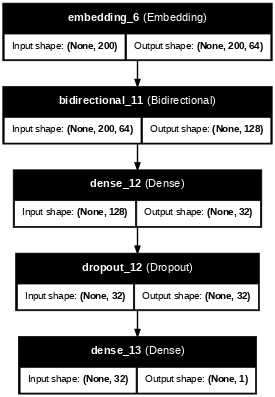

In [58]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True,show_layer_names=True, dpi=50)

**Training the model**

In [59]:
model.fit(X_train,y_train,epochs=5,batch_size=64,validation_split=0.2)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 399s 739ms/step - accuracy: 0.7003 - loss: 0.5684 - val_accuracy: 0.8574 - val_loss: 0.3388
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 356s 711ms/step - accuracy: 0.8697 - loss: 0.3240 - val_accuracy: 0.8791 - val_loss: 0.3047
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 386s 720ms/step - accuracy: 0.8982 - loss: 0.2580 - val_accuracy: 0.8845 - val_loss: 0.3201
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 395s 746ms/step - accuracy: 0.9149 - loss: 0.2132 - val_accuracy: 0.8774 - val_loss: 0.2921
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 381s 743ms/step - accuracy: 0.9233 - loss: 0.1935 - val_accuracy: 0.8817 - val_loss: 0.3283


In [60]:
loss,acc=model.evaluate(X_test,y_test)
print("Test Loss: ",loss,"Test Accuracy: ",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 224ms/step - accuracy: 0.8806 - loss: 0.3265
Test Loss:  0.32261863350868225 Test Accuracy:  0.8848000168800354


**Building a Predictive system**

In [69]:
def predict_sentiment(review):
  seq=tokenizer.texts_to_sequences([review])
  padded_seq=pad_sequences(seq,maxlen=200)
  pred=model.predict(padded_seq)
  sentiment="Positive" if pred[0][0]>0.5 else "Negative"
  return sentiment

In [70]:
# Example
Review="The direction was top-notch and brought the characters to life"
sentiment=predict_sentiment(Review)
print("Sentiment given by user is : ",sentiment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Sentiment given by user is :  Positive


In [71]:
#Another Example
Review="Bad plot, bad dialogue, bad acting"
sentiment=predict_sentiment(Review)
print("Sentiment given by user is : ",sentiment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Sentiment given by user is :  Negative


In [75]:
#Another Example
Review="Movie was not so good and a little bit boring"
sentiment=predict_sentiment(Review)
print("Sentiment given by user is : ",sentiment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
Sentiment given by user is :  Negative
